# 🌳 Trees, Gini and more!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell.

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside this notebook.
- Answer the follow-up questions in markdown format within this notebook. A few sentences are enough; there is no length requirement.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Some questions and tasks are a bit vague. You are expected to apply techniques we learned in the lectures.
- Submit this notebook to Canvas. Deliver the notebook with its outputs saved; ideally, *restart* the kernel and then *run all*.

Good luck!

---

# 🌴 Problem 1: Fit a decision tree classifier!

### ❗️ The problem
In this first problem, you must load the data and train a decision tree classifier on the provided dataset!

### 📋 Formal requirements
1. **Implementation**:
   - Load `problem1.csv`
   - Analyse the dataset (e.g. the class distribution)
   - Preprocess the training data
   - Train a decision tree classifier
   - Implement the metrics presented in the lectures
2. **Performance**: Achieve at least **0.90** classification accuracy on the test set
3. **Discussion**:
   - What preprocessing do we need to apply before training, and why?
   - Do we need to scale the features?
   - What do you observe in the decision boundary plot before and after preprocessing?
   - What happens when you increase or decrease the depth of the tree?

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [66]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
# ====================================
# YOUR CODE GOES HERE: load the data from the problem1.csv file
# ====================================
data = pd.read_csv("problem1.csv")
df = pd.DataFrame(data)
train = df[df['split'] == 'train']
test = df[df['split'] == 'test']


y
0.0    930
1.0     76
Name: count, dtype: int64
y
0.0    150
1.0    150
Name: count, dtype: int64


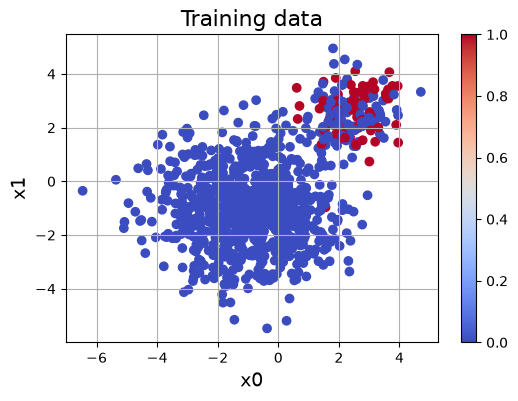

In [68]:
# ====================================
# YOUR CODE GOES HERE: let's analyse the dataset
# ====================================

# ====================================

print(train['y'].value_counts())
print(test['y'].value_counts())


plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('Training data', fontsize=16)
plt.colorbar()
plt.show()



Før, accuracy: 0.69
y
0.0    930
1.0    930
Name: count, dtype: int64

Etter, accuracy: 0.93
[[132  18]
 [  4 146]]
TPR: 0.973
FPR: 0.120
Tree depth:  2


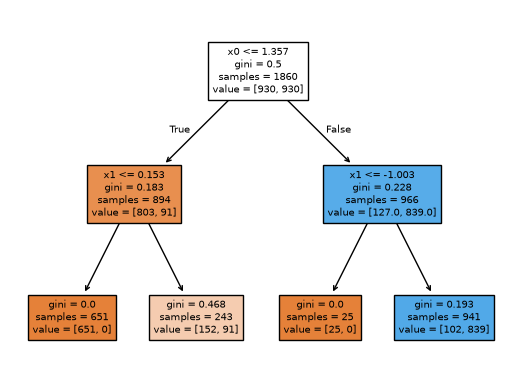

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn import tree

X_train = train[['x0', 'x1']]
y_train = train['y']
X_test = test[['x0', 'x1']]
y_test = test['y']

# ====================================
# YOUR CODE GOES HERE
# ====================================

model_before = DecisionTreeClassifier(random_state=42)
model_before.fit(train[['x0', 'x1']], train['y'])
print("Før, accuracy:", accuracy_score(y_test, model_before.predict(X_test)))

train_0 = train[train['y'] == 0]
train_1 = train[train['y'] == 1]


train_1_up = train_1.sample(n=len(train_0), replace=True, random_state=42)
train_bal = pd.concat([train_0, train_1_up])

X_train = train_bal[['x0', 'x1']]
y_train = train_bal['y']

print(y_train.value_counts())

model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)

TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
tpr = TP / (TP + FN)
fpr = FP / (FP + TN)

print()
print(f'Etter, accuracy: {accuracy:.2f}')
print(confusion_matrix(y_test, y_pred))
print(f"TPR: {tpr:.3f}")
print(f"FPR: {fpr:.3f}")

tree.plot_tree(model, feature_names=['x0', 'x1'], filled=True)
print("Tree depth: ", model.get_depth())
plt.show()


In [70]:
# ====================================
# YOUR CODE GOES HERE: report FPR and TPR alongside other metrics you find relevant (hint: see the lecture notes).
# ====================================

# ====================================

precision = precision_score(y_test, y_pred) # TP / (TP+FP)
recall = recall_score(y_test, y_pred) # TP / (TP+FN)

cMatrix = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cMatrix.ravel()
print(cMatrix)


tpr = recall
fpr = FP / (FP + TN)



print(f"True positive rate: {tpr:.3f}")
print(f"False positive rate: {fpr:.3f}")
print(f"Precision: {precision:.3f}")

[[132  18]
 [  4 146]]
True positive rate: 0.973
False positive rate: 0.120
Precision: 0.890


### ❓ What preprocessing do we need to apply before training, and why?
Treningsdataen er veldig ubalansertre, med 930 i klasse 0, og 76 i klasse 1, mens testdataen er balanserte i en 50/50-split.
Uten preprossessering optimaliserer treet for den største klassen. Som resultat finner modellen bare 44.7% av klasse 1 i testen og accuracy blir 69%.
For å veie opp for dette, oversamplet jeg den minste klassen i treningssettet. Testsettet ble ikke endret.
Etter dette gikk TPR til 97.3% og accuracy til 93%.

### ❓ Do we need to scale the features?

Nope.
Et beslutningstre deler dataene med en terskel på én feature om gangen og ser bare på hvilke rader som havner på hver side. Skalering endrer "skalaen" på en feature, men ikke rekkefølgen på radene.


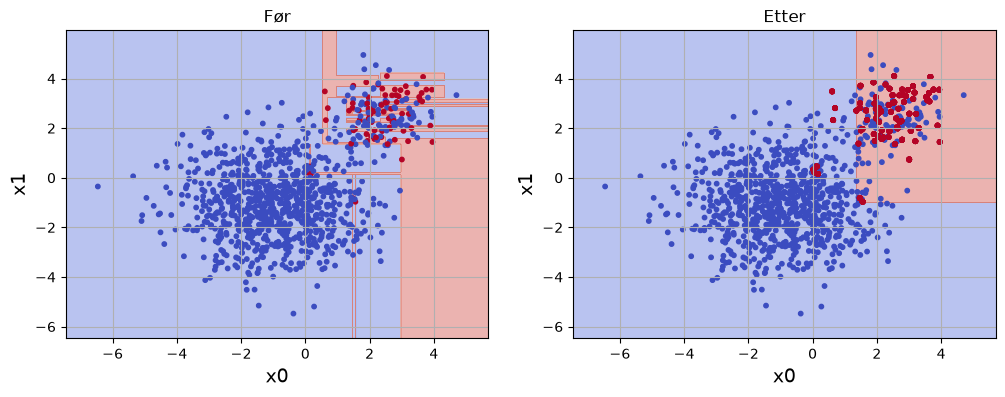

Før: TPR=0.447  FPR=0.067


In [71]:
# visualize the decision boundary
x0_min, x0_max = train['x0'].min() - 1, train['x0'].max() + 1
x1_min, x1_max = train['x1'].min() - 1, train['x1'].max() + 1
xx0, xx1 = np.meshgrid(np.arange(x0_min, x0_max, 0.01),
                       np.arange(x1_min, x1_max, 0.01))

grid = pd.DataFrame({'x0': xx0.ravel(), 'x1': xx1.ravel()})
Z = model.predict(grid)
Z = Z.reshape(xx0.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

oppsett = [
    (model_before, train[['x0', 'x1']], train['y'], 'Før'),
    (model,        X_train,             y_train,    'Etter'),
]

for ax, (m, X, y, tittel) in zip(axes, oppsett):
    Z = m.predict(grid).reshape(xx0.shape)
    ax.contourf(xx0, xx1, Z, alpha=0.4, cmap='coolwarm')
    ax.scatter(X['x0'], X['x1'], c=y, cmap='coolwarm', s=10)
    ax.grid(True)
    ax.set_xlabel('x0', fontsize=14)
    ax.set_ylabel('x1', fontsize=14)
    ax.set_title(tittel, fontsize=12)

plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, model_before.predict(X_test)).ravel()
print(f"Før: TPR={tp/(tp+fn):.3f}  FPR={fp/(fp+tn):.3f}")

### ❓ What do you observe in the decision boundary plot before and after preprocessing?

Før: Beslutningsgrensen er veldig oppdelt, grunnet overfitting. treet har pugget treningsdataene og dekker ikke de nye klasse 1-punktene i testsettet. Resultatet er TPR 0,447, FPR 0,067 og accuracy 0,69. Treet lager dermed mange små, rektangler rundt enkeltpunkter i klasse 1, og to røde felter ligger i områder uten røde treningspunkter.

Etter: Grensen er én enkel rektangel som dekker klyngen med klasse 1. Den gjør noen feil, men er generelt mye bedre: TPR 0,973, FPR 0,120 og accuracy 0,93.

Forbedringen kommer av å balansere klassene (oversampling) og begrense dybden, som hindrer treet i å pugge enkeltpunkter.

### ❓ What happens when you increase or decrease the depth of the tree?

Økt dybde gir flere splitter og en mer fleksibel modell. Ubegrenset dybde gjør at treet kan pugge treningsdataene: i Problem 1 ble grensen delt rundt enkeltpunkter og TPR bare 0,447, og i Problem 2 er accuracy 1,0 på treningsdata, men bare 0,69 i kryssvalidering. Dypt i treet inneholder nodene bare noen få passasjerer så splittene fanger støy og ikke mønstre.

Redusert dybde gir en enklere modell. Med max_depth=2 ble grensen i Problem 1 én ren rektangel som dekker klynge 1, med accuracy 0,93 på testdataene. Med dybde 1 kan det bare dra én rett linje og klarer ikke å avgrense klynge 1, som trenger to splitter, en på x0 og en på x1.

For liten dybde gir underfitting, for stor dybde gir overfitting. Riktig dybde bør velges med kryssvalidering på treningsdata.

# 🌴🌴 Problem 2: Predict Viking voyage survivors 🗡️
### ❗️ The problem
You are given a dataset with information about the passengers on Viking voyages.
Your task is to develop a decision tree classifier that predicts which Vikings **survived** a **voyage**.

### 📋 Formal requirements
1. **Implementation**:
   - Do a simple data analysis
   - Preprocess the data 
   - Train a decision tree classifier
   - Report the cross-validation score and the test accuracy
   - Try different split criteria for the decision tree
   - Plot the decision tree
   - Use a boosting technique to improve the accuracy!
   - Use Naïve Bayes to predict whether a single new voyager survives
2. **Performance**: Achieve at least **0.80** classification accuracy on the test set
3. **Discussion**:
   - Analyse the dataset. Are there any features that already predict survival better than a random guess?
   - What is the purpose of cross-validation?
   - Which split criterion do you prefer, and why?
   - What is Gini impurity? Use an example from the decision tree graph you created
   - Which terms of Bayes theorem can you estimate from this dataset, and which ones are difficult?
   - Use Naïve Bayes: does the new voyager have a higher or lower chance of surviving?

In [72]:
df = pd.read_csv('problem2.csv', keep_default_na=False, na_values=[''])

df = df.drop(columns=['name','passenger_id'])

armor_map = {"none": 0, "leather": 1, "chainmail": 2, "lamellar": 3}
df["armor"] = df["armor"].str.lower().map(armor_map)

sex_map = {"male": 0, "female": 1}   
df["sex"] = df["sex"].str.lower().map(sex_map)



Let's start by understanding the dataset.

In [ ]:
# Let's analyse the dataset
# Make some comments about what you print and what useful information it gives
# ====================================
# YOUR CODE GOES HERE: Let's analyse the dataset!
# ====================================

# ====================================

females = df[df['sex']==1]
males = df[df['sex']==0]

n_females = len(females)
n_males = len(males)


female_survivours = females['survived'].sum()
male_survivors = males['survived'].sum()


rate_female = female_survivours / n_females
rate_male = male_survivors / n_males

survivors = df['survived'].value_counts()

armor_count = df.groupby('armor', dropna=False)['survived'].agg(['mean', 'count'])
roles_grouped = df.groupby('role', dropna=False)['survived'].agg(['mean', 'count'])
ship = df.groupby('ship', dropna=False)['survived'].agg(['mean', 'count'])
destination = df.groupby('destination', dropna=False)['survived'].agg(['mean', 'count'])
clan_origin = df.groupby('clan_origin', dropna=False)['survived'].agg(['mean', 'count'])
numerics = df.groupby('survived')[['age', 'provisions_kg', 'family_aboard', 'prior_voyages']].mean()


# Totale overlevende: 44:4%: dette blir grunnlinjen for hvor relevant data er
print(f"Total survivours: {survivors}")

# 67.6& av damer og 35.7% av menn overlevde, kjønn har dermed en stor påvirkning.
print(f"Female survival rate: {rate_female:.1%}")
print(f"Male survival rate: {rate_male:.1%}")


# Overlevelsesrates med hennsyn på rustning: ingen: 27%, lær: 58%, brynje: 88% og lamellar 93%. manglende rader har 38.6%. Bedre rustning gir dermed høyere sjangse for å overleve
print(armor_count)

# Overlevelse basert på rolla: Trell har minst med 14%, så Karl med 39%, Hird har 75% og Jarl 96%. Høyere status har dermed besre sjangse for å overleve. 
# Dette henger mest sannsynlig sammen med dataen om rustning, da høyere status mest sannsynlig gir bedre rustning
print(roles_grouped)

# Skipene er ganske like, bortsett fra Sjøulven som har en lavere rate på 15%. Resten av dem ligger rundt omkring 50%
print(ship)

# Vinland var det farligste reisemålet med 21% overlevelse. Resten lå ganske jevnt rundt 50%
print(destination)

# Alle klanene lå ganske nært grunnlinjen på 44%. Hvilken klan man er i fra har dermed lite påvirkning.
print(clan_origin)


# Medianen av provisjon blandt de som døde var 18, mens de som overlevde var 33
# alder og familie om bord hadde ikke stor variasjon
print(numerics)

# manglende data: 144 rustninger, 80 aldre og 12 klaner. Dette må taes høyde for i preprossesering
print(df.isna().sum())

# Fyller inn manglende alder med median. Så på Piazza at det gikk greit
print(df['age'].describe())

Total survivours: survived
0    278
1    222
Name: count, dtype: int64
Female survival rate: 67.6%
Male survival rate: 35.7%
           mean  count
armor                 
0.0    0.266667    210
1.0    0.580357    112
2.0    0.880000     50
3.0    0.928571     14
NaN    0.385965    114
             mean  count
role                    
Hirdman  0.745455    110
Jarl     0.964286     28
Karl     0.387352    253
Thrall   0.137615    109
                 mean  count
ship                        
Bison        0.490566    106
Drakvinge    0.447619    105
Hrafnkell    0.453704    108
Ormen Lange  0.561404    114
Sjøulven     0.149254     67
                 mean  count
destination                 
Iceland      0.479592     98
Lindisfarne  0.545455    132
Miklagard    0.416667     84
Normandy     0.443548    124
Vinland      0.209677     62
                 mean  count
clan_origin                 
Borg         0.478632    117
Kaupang      0.433333     90
Nidaros      0.430605    281
NaN          

### ❓ Are there any features that already predict survival better than a random guess?
Totalt overlevde 222 av 500 (44,4 %), og det er utgangspunktet vi bruker til å sammenligne. 

- rolle: Jarl 96 % og Hirdman 75 % overlevde, mot Karl 39 % og Thrall 14 %.
- rustning: overlevelsen stiger med bedre rustning: ingen 27 %, lær 58 %, kjedepanser 88 %, lamellar 93 %.
- kjønn: kvinner 68 %, menn 36 %.
- skip: Sjøulven bare 15 %, mens de andre skipene ligger på 45 til 56 %.
- destinasjon: Vinland bare 21 %, mens de andre ligger på 42 til 55 %.
- kilo mat og tidligere reiset: de som overlevde hadde i snitt 33,6 kg og 2,8 tidligere reiser, mot 18,0 kg og 1,2 for de som døde.

Svake prediktorer er klan (43 til 48 %, nær utgangspunktet), alder (snitt 28,8 mot 30,7 år) og familie om bord (1,15 mot 1,11). Forskjellene er små i forhold til tilfeldig variasjon (rundt ±5 prosentpoeng for grupper på ca. 100). Manglende rustning (114 rader) har 38,6 % overlevelse, så mangelen er informativ og bør ikke droppes.

In [74]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
target = 'survived'
# ====================================
# YOUR CODE GOES HERE: Train the model:)
# ====================================

# ====================================

    # separer features fra fasit
X = df.drop(columns=[target])
y = df[target]

X = pd.get_dummies(X, columns=['role', 'ship', 'destination', 'clan_origin'], dtype=int)
X['armor'] = X['armor'].fillna(-1)

 #Splitt i trening og test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y ,random_state=42)

medi = X_train['age'].median()

X_train['age'] = X_train['age'].fillna(medi)
X_test['age']  = X_test['age'].fillna(medi)

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

    # resultat
y_pred = dtc.predict(X_test)
a = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(dtc, X_train, y_train, cv=5)


print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test accuracy: {a:.4f}")
print(f"Train accuracy: {dtc.score(X_train, y_train):.4f}")

CV Accuracy: 0.690 ± 0.066
Test accuracy: 0.7600
Train accuracy: 1.0000


### ❓ What is the purpose of cross validation?
Kryssvalidering estimerer hvor godt en modell tilpasser seg til ny data uten å referere til testdata, mens man maksimerer bruken av den begresete dataen og avslører overfitting. Treningsdata deles inn i like store k-"folder", og modellen trenes på k-1 folden og valideres på den siste. Dette gjentas frem til hver fold har blitt brukt til validering en gang. 

In [75]:
# Compare the different split criteria
# ====================================
# YOUR CODE GOES HERE: try the different split criteria (gini, entropy, log_loss)
# and report the cross-validation and test accuracy for each
# ====================================

# Gini
dtc_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dtc_gini.fit(X_train, y_train)

cv_gini = cross_val_score(dtc_gini, X_train, y_train, cv=5)
test_gini = accuracy_score(y_test, dtc_gini.predict(X_test))

# Entropy
dtc_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_entropy.fit(X_train, y_train)

cv_entropy = cross_val_score(dtc_entropy, X_train, y_train, cv=5)
test_entropy = accuracy_score(y_test, dtc_entropy.predict(X_test))

print("### GINI ###")
print(f"CV gini: {cv_gini.mean():.3f} ± {cv_gini.std():.3f}")
print(f"Test gini: {test_gini:.4f}")

print("### ENTROPY ###")
print(f"CV entropy: {cv_entropy.mean():.3f} ± {cv_entropy.std():.3f}")
print(f"Test entropy: {test_entropy:.4f}")

### GINI ###
CV gini: 0.690 ± 0.066
Test gini: 0.7600
### ENTROPY ###
CV entropy: 0.688 ± 0.033
Test entropy: 0.7300


### ❓ Try different DecisionTreeClassifier criteria, report what accuracy you get. Which criterion do you prefer?
Gini ga CV 0,690 ± 0,066 og test 0,76, mens entropy ga CV 0,688 ± 0,033 og test 0,73. I sklearn er log_loss det samme som entropy (de ga like tall når jeg kjørte det tidligere).

Forskjellen mellom kriteriene er liten. Jeg foretrekker gini fordi den gir minst like god accuracy, er standard i sklearn og er litt raskere å beregne siden den ikke trenger logaritme. Valget har likevel liten praktisk betydning her, men pga at gini ligger litt høyere både i cv og test ville jeg gått for den, men forskjellene er veldig små.

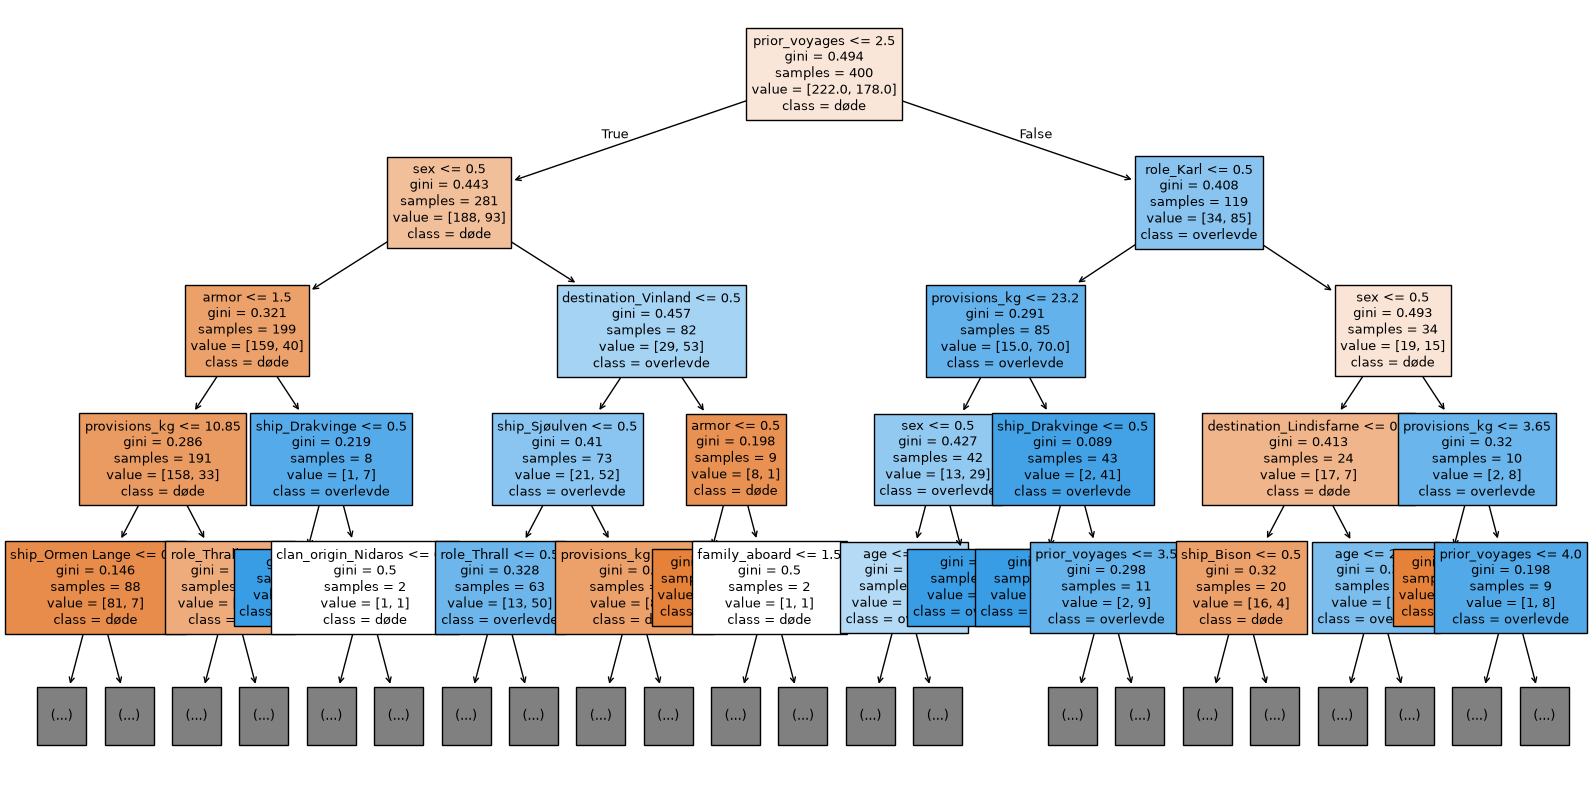

In [76]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# ====================================
# YOUR CODE GOES HERE: Plot the decision tree nodes!
# ====================================

plt.figure(figsize=(20, 10))
plot_tree(dtc, feature_names=X_train.columns, class_names=['døde', 'overlevde'],
          max_depth=4, filled=True, fontsize=9)

plt.show()

### ❓ What is Gini? Use an example from the decision tree graph you created.
Gini er et kriterium som prøver å splitte og kategorisere noder til å bli "rene", altså ikke blandet. 
En ren node vil ha en gini (impurity) på 0, og en 50/50 node vil gi 0.5

Eksempel fra grafen: Rotnoden har 400 passasjerer med value = [222, 178], som gir Gini = 1 − (222/400)² − (178/400)² = 0,494. Det er nesten maks, fordi klassene er blandet. Lenger ned derimot, har noden ship_Drakvinge <= 0.5 (på høyre side) har value = [2, 41] og Gini = 1 − (2/43)² − (41/43)² = 0,089, altså nesten ren. (dermed ganske bra)

## Improving the results with boosting 🚀

In [77]:
from sklearn.ensemble import AdaBoostClassifier
# ====================================
# YOUR CODE GOES HERE: Use AdaBoostClassifier to get even better results!
# ====================================
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
ada_cv_scores = cross_val_score(ada, X_train, y_train, cv=5)
# ====================================
ada_acc = accuracy_score(y_test, y_pred_ada)

print(f"AdaBoost CV Accuracy: {ada_cv_scores.mean():.3f} ± {ada_cv_scores.std():.3f}")
print(f"AdaBoost test accuracy: {ada_acc:.4f}")

AdaBoost CV Accuracy: 0.802 ± 0.057
AdaBoost test accuracy: 0.7600


Kravet på 0.80 ble ikke nådd, men det ligger innenfor rekkevide for tilfedig variasjon på CV-resultatet på 0.80

### ❓ Try estimating the factors of Bayes theorem using this dataset. What terms can you estimate and which ones are difficult and why?
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$


Dette blir mer komplisert når man skal finne sannsynlighetener for å overleve, og ta hennsyn til mange forskjellige komboer av features. For eksempel har Endre i oppgaven under hatt 12 tidligere reiser, noe som måtte taes høyde for da ingen i datasettet hadde hatt så mange, og jeg måtte justere grensen for tidligere reiser ned til 5 og over. 

Det er lettere å estimere når det er færre features, f.eks om kriteriene er "kvinne" og "overlevde", men ettersom det blir flere kombinasjoner av features, vil sannsynligheten for akurat den kombinasjonen bli mer og mer spesifikk og dermed vanskligere å estimere

In [78]:
# ====================================
# YOUR CODE GOES HERE: estimate the terms of Bayes theorem you can
# ====================================

    # P(A) - antall overlevende
p_a = df['survived'].mean()

    # P(B) - andel som er Jarl
p_b = (df['role'] == 'Jarl').mean()

survivors_df = df[df['survived'] == 1]
p_b_given_a = (survivors_df['role'] == 'Jarl').mean()

jarl_df = df[df['role'] == 'Jarl']
p_a_given_b = jarl_df['survived'].mean()


bayes = (p_b_given_a * p_a) / p_b


print(p_a)
print(p_b)
print(p_b_given_a)
print(p_a_given_b)
print(bayes, p_a_given_b)


0.444
0.056
0.12162162162162163
0.9642857142857143
0.9642857142857144 0.9642857142857143


### ❓ Use Naïve Bayes. Does Endre have a higher or lower chance of surviving than dying on a voyage?

A voyager named **Endre** is about to set sail. This is what we know about him:

| Feature | Value |
| --- | --- |
| `sex` | Male |
| `age` | 25 |
| `role` | Hirdman |
| `ship` | Drakvinge |
| `destination` | Normandy |
| `clan_origin` | Nidaros |
| `armor` | Chainmail |
| `provisions_kg` | 49 |
| `family_aboard` | 2 |
| `prior_voyages` | 12 |

Does he have a **higher or lower** chance of surviving the voyage?

I følge Naive Bayes, er sannsynligheten for at Endre overlever ca 99.5%. 

In [79]:
# ====================================
# YOUR CODE GOES HERE: Naïve Bayes
# You can either do this by hand or with code.
# Do not import libraries.
# ====================================
dead_df = df[df['survived']==0]

p_male_given_dead = (dead_df['sex'] == 0).mean()
p_male_given_surived = (survivors_df['sex']==0).mean()

p_hird_given_survived = (survivors_df['role'] == 'Hirdman').mean()
p_hird_given_dead = (dead_df['role'] == 'Hirdman').mean()

p_ship_given_survived = (survivors_df['ship'] == 'Drakvinge').mean()
p_ship_given_dead = (dead_df['ship'] == 'Drakvinge').mean()

p_dest_given_survived = (survivors_df['destination'] == 'Normandy').mean()
p_dest_gived_dead = (dead_df['destination'] == 'Normandy').mean()

p_clan_given_survived = (survivors_df['clan_origin'] == 'Nidaros').mean()
p_clan_given_dead = (dead_df['clan_origin'] == 'Nidaros').mean()

p_armor_given_survived = (survivors_df['armor'] == 2).mean()
p_armor_given_dead = (dead_df['armor'] == 2).mean()

p_fam_given_survived = (survivors_df['family_aboard'] == 2).mean()
p_fam_given_dead = (dead_df['family_aboard'] == 2).mean()

survived_age = survivors_df['age'].dropna()
dead_age = dead_df['age'].dropna()

p_age_given_surv = ((survived_age >= 20) & (survived_age <= 30)).mean()
p_age_given_dead = ((dead_age >= 20) & (dead_age <= 30)).mean()

p_prov_given_surv = ((survivors_df['provisions_kg'] >= 44) & (survivors_df['provisions_kg'] <= 54)).mean()
p_prov_given_dead = ((dead_df['provisions_kg'] >= 44) & (dead_df['provisions_kg'] <= 54)).mean()

n_prov_surv = ((survivors_df['provisions_kg'] >= 44) & (survivors_df['provisions_kg'] <= 54)).sum()
n_prov_dead = ((dead_df['provisions_kg'] >= 44) & (dead_df['provisions_kg'] <= 54)).sum()

p_voy_given_surv = (survivors_df['prior_voyages'] >= 5).mean()
p_voy_given_dead = (dead_df['prior_voyages'] >= 5).mean()

n_voy_surv = (survivors_df['prior_voyages'] >= 5).sum()
n_voy_dead = (dead_df['prior_voyages'] >= 5).sum()

p_dead = 1 - p_a
score_surv = (p_a
              * p_male_given_surived
              * p_hird_given_survived
              * p_ship_given_survived
              * p_dest_given_survived
              * p_clan_given_survived
              * p_armor_given_survived
              * p_fam_given_survived
              * p_age_given_surv
              * p_prov_given_surv
              * p_voy_given_surv)
score_dead = (p_dead
              * p_male_given_dead
              * p_hird_given_dead
              * p_ship_given_dead
              * p_dest_gived_dead
              * p_clan_given_dead
              * p_armor_given_dead
              * p_fam_given_dead
              * p_age_given_dead
              * p_prov_given_dead
              * p_voy_given_dead)


p_survive = score_surv / (score_surv + score_dead)
print(p_survive)


0.994741886815779
